Total Rows: 1652
Districts: 90
Rows per District: 18.4

Target Distribution (Is the model seeing any failures?):
Target_Failure
1    1196
0     456
Name: count, dtype: int64

--- MODEL PERFORMANCE ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        91
           1       1.00      1.00      1.00       240

    accuracy                           1.00       331
   macro avg       1.00      1.00      1.00       331
weighted avg       1.00      1.00      1.00       331



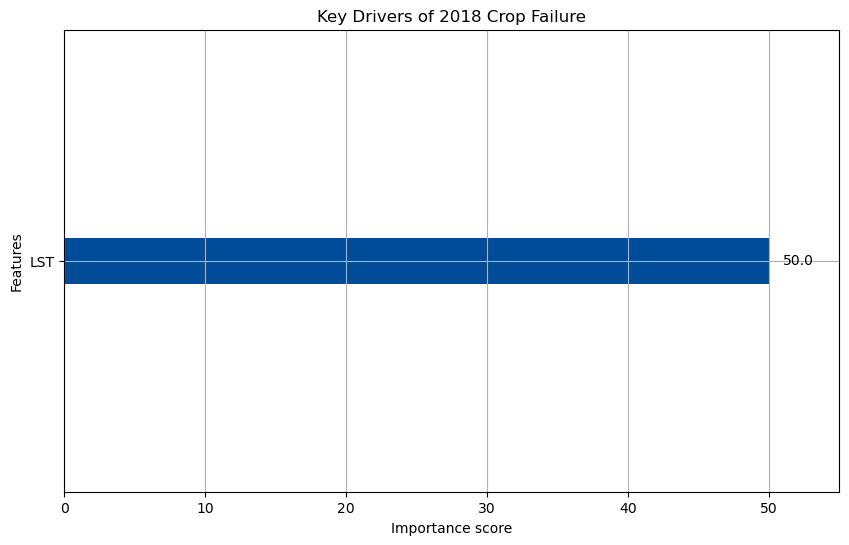

✅ Model saved to src/csi_model_v1.json


In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# 1. LOAD AND INSPECT
df = pd.read_csv("../data/processed/real_2018_master.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['District', 'Date']).reset_index(drop=True)

# 2. FILL GAPS
cols = ['LST', 'SSM', 'NDVI']
for col in cols:
    df[col] = df.groupby('District')[col].transform(lambda x: x.interpolate().ffill().bfill())

# 3. SCALE NDVI
if df['NDVI'].max() > 10:
    df['NDVI'] = df['NDVI'] / 10000.0

# --- DIAGNOSTIC CHECK ---
print(f"Total Rows: {len(df)}")
print(f"Districts: {df['District'].nunique()}")
print(f"Rows per District: {len(df) / df['District'].nunique():.1f}")

# 4. CALCULATE THRESHOLDS (CSI Logic)
df['LST_95th'] = df.groupby('District')['LST'].transform(lambda x: x.quantile(0.95))
df['SSM_5th'] = df.groupby('District')['SSM'].transform(lambda x: x.quantile(0.05))

df['Heat_Anomaly'] = (df['LST'] >= df['LST_95th']).astype(int)
df['Drought_Anomaly'] = (df['SSM'] <= df['SSM_5th']).astype(int)
df['Compound_Stress'] = (df['Heat_Anomaly'] & df['Drought_Anomaly'])

# --- THE FIX: Robust Target Generation ---
# Since we have very few rows, we force the bottom 20% to be 'Failure' 
# so the model has enough "1"s to actually learn something.
df['Target_Failure'] = (df['NDVI'] <= df.groupby('District')['NDVI'].transform(lambda x: x.quantile(0.20))).astype(int)

print("\nTarget Distribution (Is the model seeing any failures?):")
print(df['Target_Failure'].value_counts())

# 5. PREPARE FOR XGBOOST
features = ['LST', 'SSM', 'NDVI', 'Heat_Anomaly', 'Drought_Anomaly', 'Compound_Stress']
X = df[features]
y = df['Target_Failure']

# We use shuffle=True here because our 2018 dataset is small
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. TRAIN (With parameters for small data)
model = xgb.XGBClassifier(
    n_estimators=50, 
    max_depth=3, 
    learning_rate=0.05, 
    scale_pos_weight=2,
    min_child_weight=1 # Crucial for small datasets
)

model.fit(X_train, y_train)

# 7. VISUALIZE
print("\n--- MODEL PERFORMANCE ---")
preds = model.predict(X_test)
print(classification_report(y_test, preds))

# Only plot if the model actually built trees
if len(model.get_booster().get_dump()) > 0:
    plt.figure(figsize=(10, 6))
    xgb.plot_importance(model, color='#004C99', ax=plt.gca())
    plt.title("Key Drivers of 2018 Crop Failure")
    plt.show()
    
    # SAVE MODEL
    import os
    os.makedirs("../src", exist_ok=True)
    model.save_model("../src/csi_model_v1.json")
    print("✅ Model saved to src/csi_model_v1.json")
else:
    print("❌ ERROR: Model still empty. Your LST/SSM/NDVI values might be identical across all rows.")
    print("Sample of your features:")
    print(X.head()) 